In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "ml/"

# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [2]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

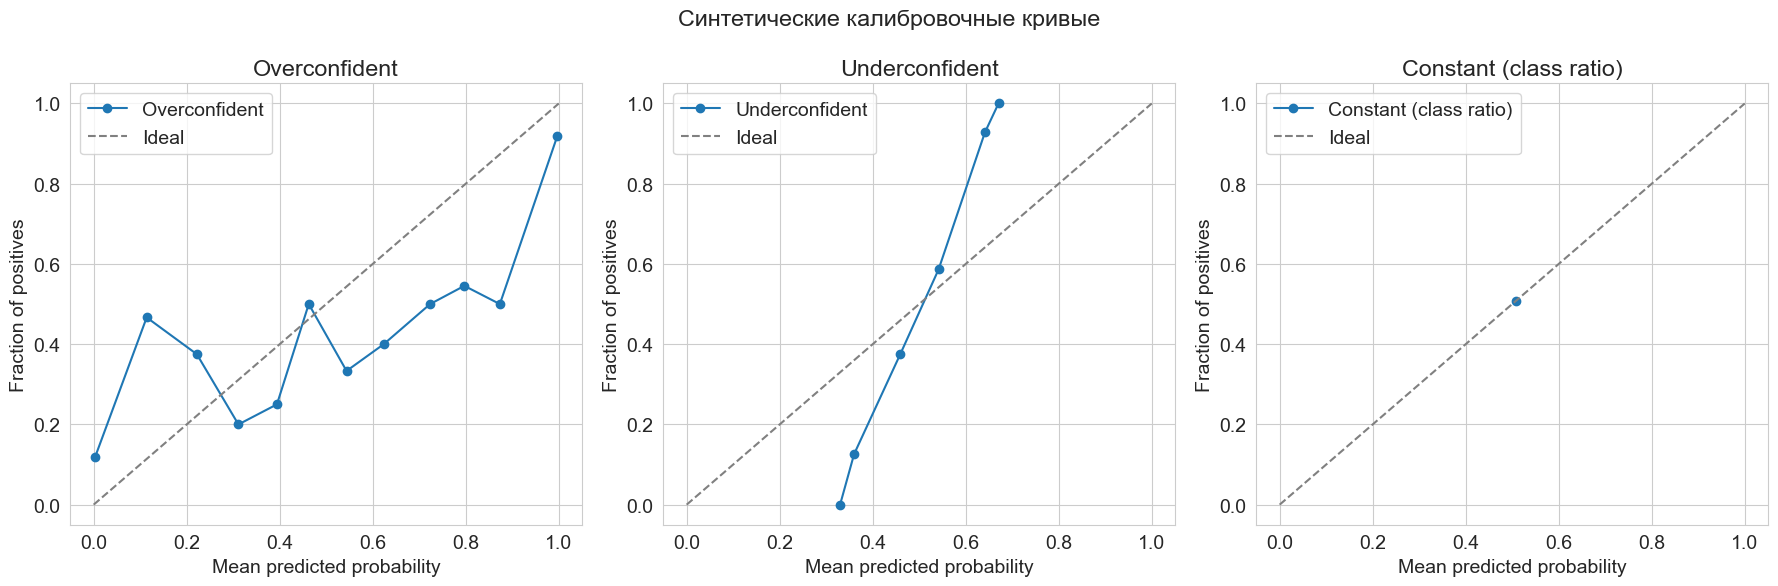

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [6]:
data = pd.read_csv(r'Z:\IT\spbu_ml_2026\ml\riceClassification.csv')


Отмасштабируем данные и подготовим трейн и тест.

In [7]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов

,count,share
Class,,
0,8200,0.450921
1,9985,0.549079


???? ?????? 1: 0.549
????????? majority/minority: 1.22


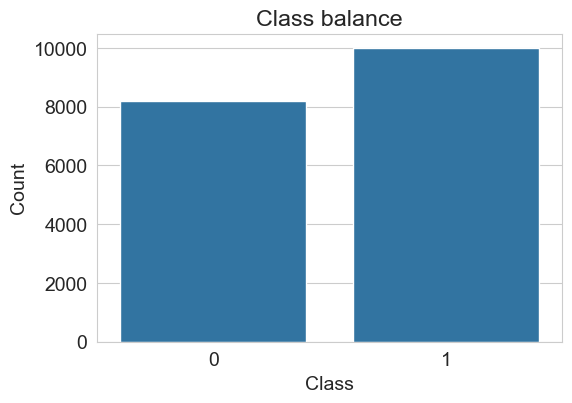

In [8]:
class_counts = y.value_counts().sort_index()
class_share = y.value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    'count': class_counts,
    'share': class_share,
})
display(balance)

print(f'???? ?????? 1: {y.mean():.3f}')
print(f'????????? majority/minority: {class_counts.max() / class_counts.min():.2f}')

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

??????: ????? ??????? ??? decision function ? ????????????? ??????????

**?????:** ??? ???????? ????????????? ????????? `decision_function` ?????????? ???????? ????, ?? ???? ????? ??????????? ?????????????? ??????:

$$f(x) = w^T x + b = \log 
rac{P(y=1 \mid x)}{P(y=0 \mid x)}.$$

??????????? ????? ?????????? ?????????: $P(y=1 \mid x)=\sigma(f(x)) = 
rac{1}{1+e^{-f(x)}}$.

In [9]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [10]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506552], shape=(7274,))

In [11]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [12]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


In [13]:
# LinearSVC ?? ????? predict_proba: ??? ?? ??????????????? ???????????,
# ? ?????? ??????? ?????? ????????? margin score ? [0, 1].
svc_sigmoid_pred = expit(svc.decision_function(X_test))
print('SVC ROC-AUC (sigmoid over margin):', roc_auc_score(y_test, svc_sigmoid_pred))
svc_sigmoid_pred[:10]

SVC ROC-AUC (sigmoid over margin): 0.9991453206707389


array([0.9630022 , 0.87568987, 0.87407908, 0.73682724, 0.96400894,
       0.02721138, 0.66854736, 0.85877309, 0.08028908, 0.88893111])

In [14]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [15]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [16]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [17]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [18]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]], shape=(7274, 2))

In [19]:
lr.classes_

array([0, 1])

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

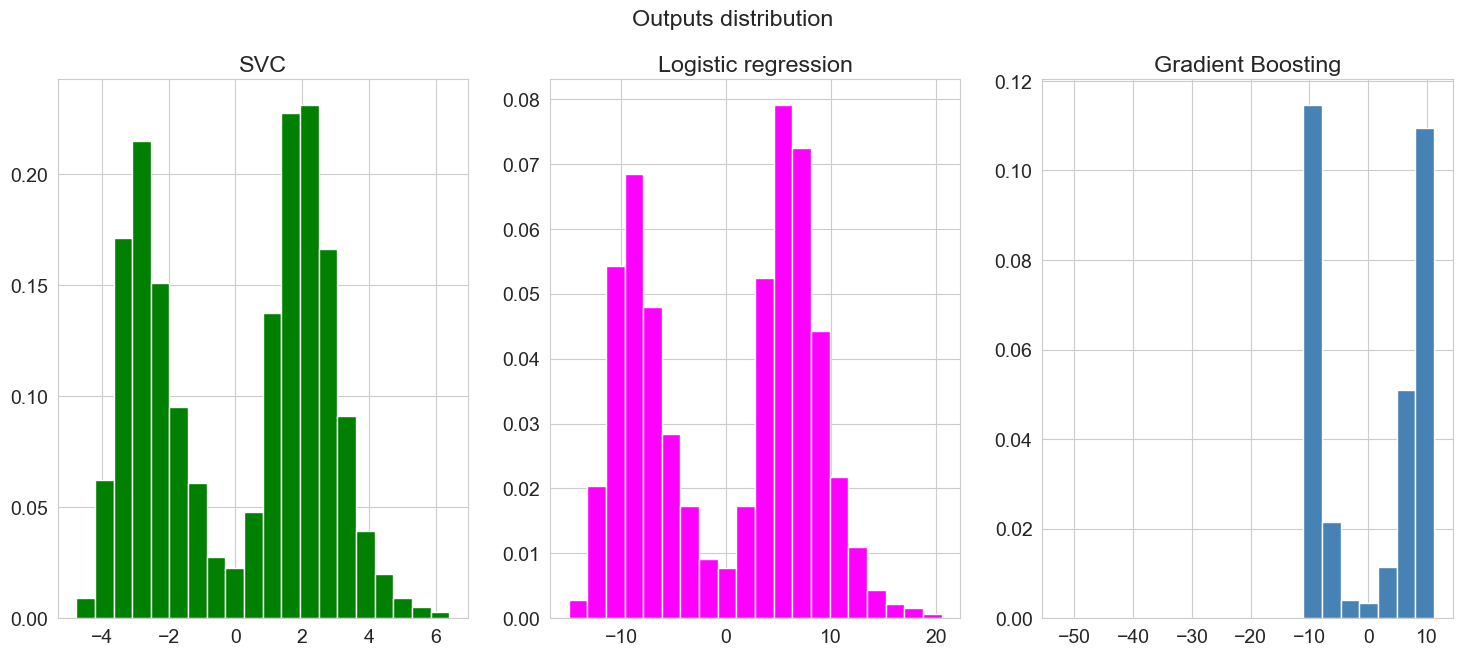

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

?? ?????, ??? ????? ????? ????????? ????? ???????????? ????????. ?? ??? ?????????? ???????????? ??? ????? ????????? ?? ? ?????????? 
$[0,1]$. ? ????????????? ?????????? ????????: ????? ???????? ???????? ??? ????????, ???? ?????? ? ????????? ???, ????? $\sigma (W^Tx)$
 ?????????? ???????????. ??? SVC ? ??? ??? ????? ?????, ??????? ????????????? ???????????????? ????? ???????-????????.

??????: ? ??? ??????????? ??????????? ??? ?????????

**?????:** ??? `GradientBoostingClassifier` ??????? ????????????? ??????? ? ?????? ????? `decision_function`. ? ???????? ?????? ???? ???? ???????????????? ??? ?????, ??????? ??????????? ?????????????? ?????? ?????????? ????????? $\sigma(f(x))$. ? ???????????? ????? ????? ??????????? ? ??????????? softmax-???????????.

In [21]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

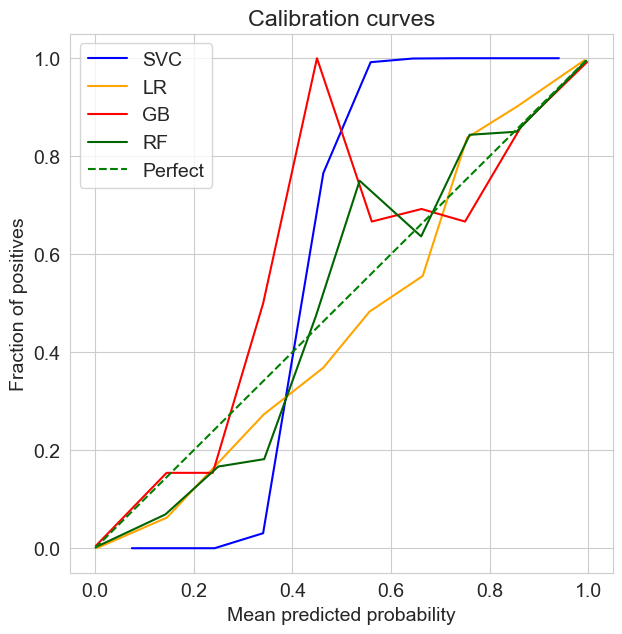

In [22]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()


Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

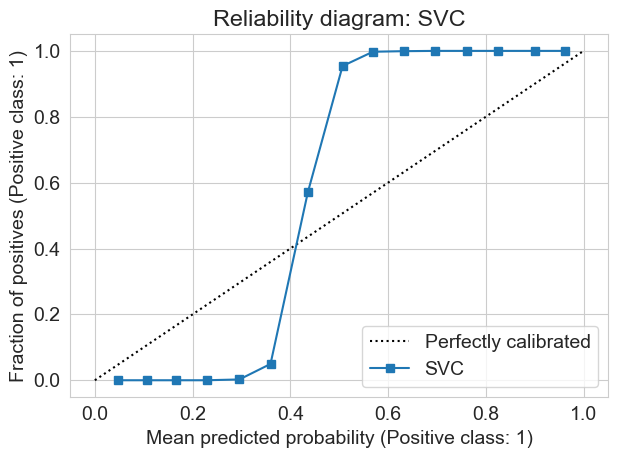

In [23]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

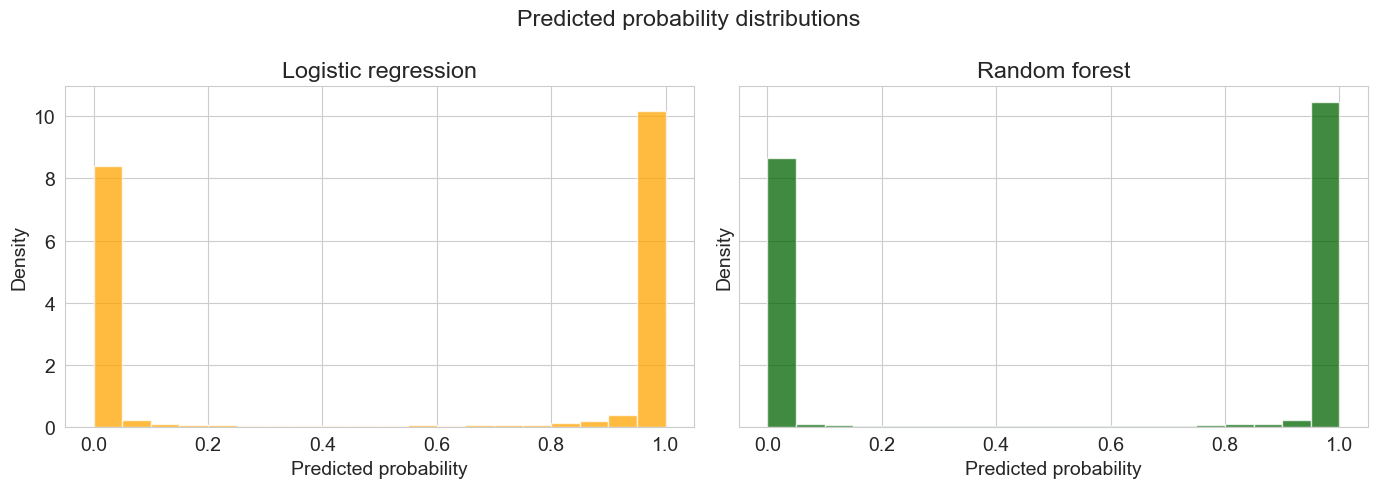

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pred, name, color in [
    (axs[0], lr_pred, 'Logistic regression', 'orange'),
    (axs[1], rf_pred, 'Random forest', 'darkgreen'),
]:
    ax.hist(pred, bins=20, range=(0, 1), density=True, alpha=0.75, color=color)
    ax.set_title(name)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')

plt.suptitle('Predicted probability distributions')
plt.tight_layout()
plt.show()

# ?????????? ??????
????? ??? ???????? ?????? ???????? $f(x)$ (????? ?? ???? ?????????????). ????? ???????? ??????????? ???????? ???:

$$P(y = 1 | x) = 
rac{1}{1+\exp (af(x) + b)},$$

??? $a, b$ -- ????????? ?????????. ??? ????????? ????????????? ??????? ????????? ????????????? (??????????? ????????????? ??????? ??????):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] 	o min_{a,b}$$

????????: ?? ??????? $f(x)$ ??????? ?????? ????????? ????????????? ????????? ??? ?????????????; ??????????????? ???????????? ? $\sigma(af(x)+b)$.

??????: ?? ????? ??????? ????????? ???????

**?????:** ?????????? ????? ??????? ?? ????????????? ??????? ??? ????? out-of-fold ????????????, ? ?? ?? ??? ?? ????????, ?? ??????? ????????? ??????? ??????. `CalibratedClassifierCV(cv=3)` ??? ??? ??????? ??????? ?????? ?? ?????? ? ??????????? ?????????? ?? ?????????? ??????.

????? ????? ????????? ??? ????????? ???????????? ???????? ????? ???????? ? NLL ($y_i$ ? $1-y_i$) ?? ????????? ????????:

$t_{+} = 
rac{N_{+} + 1}{N_{-} + 2}$ ??? ????????????? ???????? ?

$t_{-} = 
rac{1}{N_{-} + 2}$ ??? ?????????????, ??? $N_{-}$ ? $N_{+}$ ????? ?????????? ? ?????????? ??????? ? ???????. 

?????????? ?????? ????? ??????????? ??? ?????????? ????????????? ????????? ?????? ???????????? ??????? ????????? ? ??????????? ??????????????. 

?????????? ?????? ??????? ??????????? ? SVM, ?? ??? ????? ?????? ??????????????? ????? ?????????. ? ?????, ????? ????????, ??? ???? ????? ?????? ????????, ???? ??? ??????? ?? ???????? ??????? ????????????? ??????????? ???????????? ????????? ? ??????????? ??????????? (????????? [?????](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

?????? ??? ?????????? ????????? ? ??????? ?????? ??????????????? ??????? ??????????, ???? ?? ????????? ????-?????????? (? ????????????? ????-?????????????) ??? ?????????? ??????? (??? ????????????). 

In [25]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [26]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [27]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('Random forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

Random forest ROC-AUC: 0.999082664029135


In [28]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990612569792324


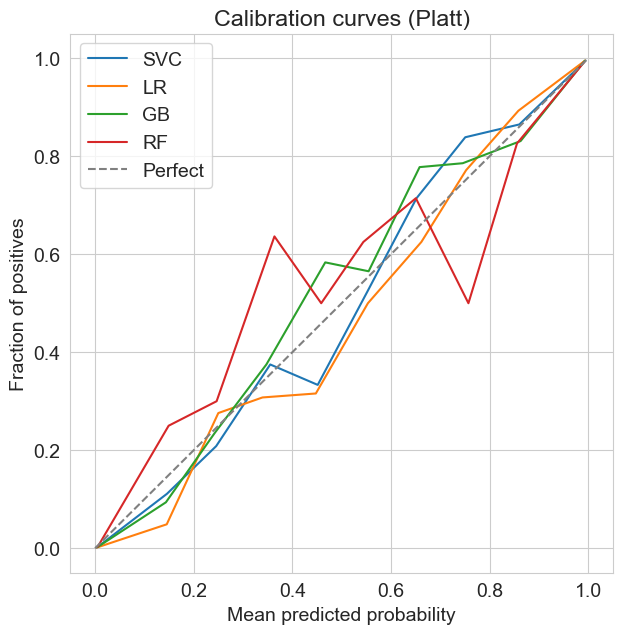

In [29]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [30]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [31]:
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_lr_pred))

LR ROC-AUC: 0.9989381569026097


In [32]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.998995204210282


In [33]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991284163514756


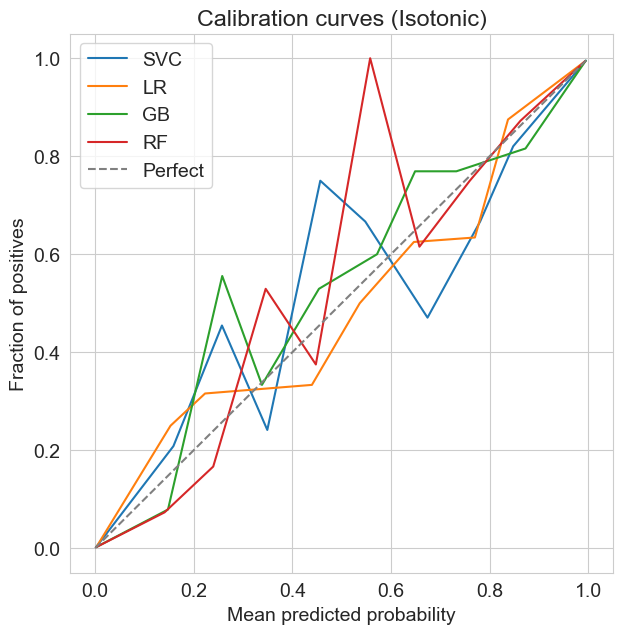

In [34]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, олна переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [35]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798889934
Linear binary-ECE =  0.0034477460600426638
GB binary-ECE =  0.003472623806893145
RF binary-ECE =  0.002610568433671964
Isotonic:
SVC binary-ECE =  0.0020864508068445986
Linear binary-ECE =  0.002150623426981368
GB binary-ECE =  0.002283717139315842
RF binary-ECE =  0.002056138427129562


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

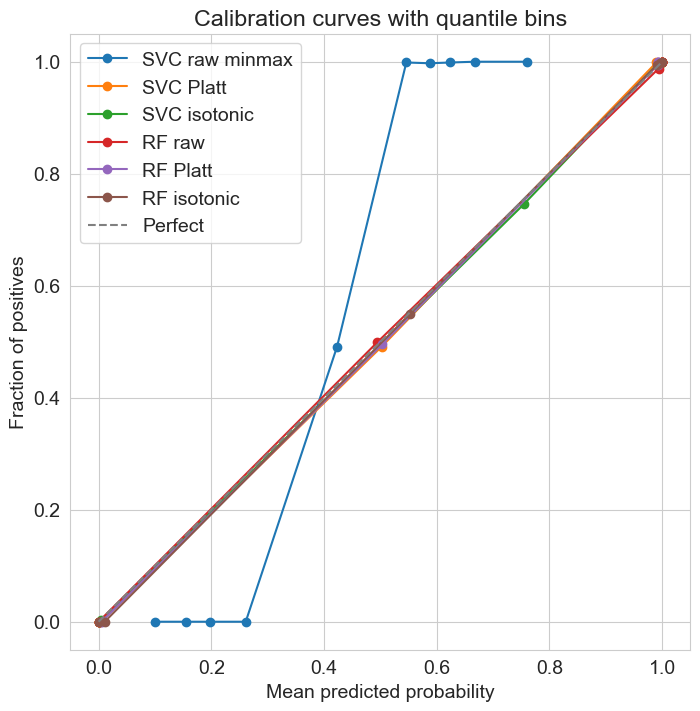

In [ ]:
plt.figure(figsize=(8, 8))
for name, pred in [
    ('SVC raw minmax', svc_pred),
    ('SVC Platt', sigmoid_svc_pred),
    ('SVC isotonic', isotonic_svc_pred),
    ('RF raw', rf_pred),
    
    ('RF Platt', sigmoid_rf_pred),
    ('RF isotonic', isotonic_rf_pred),
]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')
    plt.plot(pred_prob, true_prob, marker='o', label=name)

plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves with quantile bins')
plt.legend()
plt.show()

**??????**: ??? ????? ???????????? MCE/ECE ??? ??????????????? ??????? ???????? ???????.

**?????:** ???? ??? ?????????? ????????.

1. Top-label ECE: ????? ??????????? ??????????? ?????? $c_i=\max_k \hat p_{ik}$ ? ???????????? $a_i=I(y_i=rg\max_k \hat p_{ik})$:
$$ECE_{top}=\sum_{m=1}^{M}
rac{|B_m|}{N}\left|
rac{1}{|B_m|}\sum_{i\in B_m}a_i-
rac{1}{|B_m|}\sum_{i\in B_m}c_i
ight|.$$

2. Classwise ECE: ??????? one-vs-rest ECE ??? ??????? ?????? ? ?????????:
$$ECE_{cw}=
rac{1}{K}\sum_{k=1}^{K}\sum_{m=1}^{M}
rac{|B_{m,k}|}{N}\left|
rac{1}{|B_{m,k}|}\sum_{i\in B_{m,k}}I(y_i=k)-
rac{1}{|B_{m,k}|}\sum_{i\in B_{m,k}}\hat p_{ik}
ight|.$$

?????????? ??? MCE ?????? ?????????? ????? ??????? ???????? ?? ?????, ? ??? classwise-?????? ??? ???????? ??? ??????? ?? ???????.

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [37]:
class_prior = y_train.mean()
constant_prior_pred = np.full_like(y_test, fill_value=class_prior, dtype=float)
optimistic_positive_pred = np.where(y_test == 1, 0.9, class_prior)

for name, pred in [
    ('Constant class prior', constant_prior_pred),
    ('0.9 for positives, prior for negatives', optimistic_positive_pred),
]:
    pred = np.clip(pred, 1e-15, 1 - 1e-15)
    print(name)
    print('ECE:', binary_ECE(y_test, pred))
    print('Brier:', brier_score_loss(y_test, pred))
    print('Log-loss:', log_loss(y_test, np.column_stack([1 - pred, pred])))
    print()

Constant class prior
ECE: 0.00091650627806783
Brier: 0.24764577542222804
Log-loss: 0.6884313246773119

0.9 for positives, prior for negatives
ECE: 0.302911612179902
Brier: 0.1417800362082307
Log-loss: 0.4177404048756519



????? ????????? ??????????????? ? ?? ?????? ???????.

**Brier score.** ???? ???? ?? ?????????? ??????, ??????? ???????? ???????? ??????? ????? ?????????????? ????????????? ? $ y_i $ (???????? ????????, ??? $ y_i $  - ??? ???? 0, ???? 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
??? ????????? ??????, ?
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
??? ????????????.

**??????**: ????? ???????? ????????????? ?????? ??????????? ????? ???????????? ? ??????????? ???????? ?? ?????? ??????????

**?????:** ??? ?????? Brier score, ??? ?????. ??????? ????? 0: ?????? ???? ??????????? 1 ????????? ?????? ? 0 ?????????. ? ???????? ?????? ???????? ???????? Brier score ????? 1, ???? ?????? ?????? ?????????? ? ???????????? 1 ??? ????????? ??????. ? ??????????????? ??????? ? ?????? ?? ??????? ???????? ????? 2: ???????? ????? ??????? 0, ? ???? ???????? ????? ??????? 1.

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [38]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.031276285531666545
Platt LR = 0.0333262455198998
Platt GB = 0.03331647881716411
Platt RF = 0.038908642002126646
Isotonic SVC = 0.030862017939829182
Isotonic LR = 0.033625055910619976
Isotonic GB = 0.03191541409933446
Isotonic RF = 0.0317766445159259


In [39]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964847236
Linear brier score =  0.008657533565358946
GB brier score =  0.008325371462496654
RF brier score =  0.008416712034272293
Isotonic:
SVC brier score =  0.008210667087880846
Linear brier score =  0.008753390327467456
GB brier score =  0.008318772289237032
RF brier score =  0.008147859165350083


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [40]:
raw_preds = {
    'SVC raw minmax': svc_pred,
    'LR raw': lr_pred,
    'GB raw': gb_pred,
    'RF raw': rf_pred,
}

raw_quality = []
for name, pred in raw_preds.items():
    pred = np.clip(pred, 1e-15, 1 - 1e-15)
    raw_quality.append({
        'model': name,
        'ECE': binary_ECE(y_test, pred),
        'Brier': brier_score_loss(y_test, pred),
        'Log-loss': log_loss(y_test, np.column_stack([1 - pred, pred])),
        'ROC-AUC': roc_auc_score(y_test, pred),
    })

display(pd.DataFrame(raw_quality).sort_values('ECE'))

,model,ECE,Brier,Log-loss,ROC-AUC
3,RF raw,0.002561,0.008120,0.031454,0.999101
2,GB raw,0.005609,0.008841,0.045511,0.998357
1,LR raw,0.006612,0.008709,0.034384,0.999002
0,SVC raw minmax,0.285346,0.103584,0.368520,0.999145


????, ?? ????????????? ???? ??????????????. ?????? ?? ????? ???????, ??? ?????????? ??????? ????? ?????. ???, ?? ???? ????????, f1 ?? ?????? ?????? ??????????, ??? ??? ?????? ?? ??????? ?????????? ??????????? ?? ?????? ?????? ??????????. ??? ?? ????
?????? **??????**: ????????? ?? ????? ?????????? ROC-AUC ? ???? ?????? ?? ?? ???????? ?? ?????? ??? ??????????

**?????:** ???? ?????????? ???????? ?????? ?????????? ??????????????? ??????, ROC-AUC ?? ?????????, ?????? ??? ROC-AUC ??????? ?????? ?? ??????? ????????. ?? ???????? `CalibratedClassifierCV` ??????????? ??????? ?????? ?? ?????? ? ????????? ??, ? ????????????? ????????? ????? ?????? ?????????? ???????? ?????????? ????????, ??????? ROC-AUC ????? ?????? ??????????.

**Задание**: Обучите дерево решений и случайный лес.

In [41]:
dt_final = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(X_train, y_train)
rf_final = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=SEED).fit(X_train, y_train)

dt_pred = dt_final.predict_proba(X_test)[:, 1]
rf_final_pred = rf_final.predict_proba(X_test)[:, 1]

print('Decision tree ROC-AUC:', roc_auc_score(y_test, dt_pred))
print('Random forest ROC-AUC:', roc_auc_score(y_test, rf_final_pred))
print('Decision tree ECE:', binary_ECE(y_test, dt_pred))
print('Random forest ECE:', binary_ECE(y_test, rf_final_pred))

Decision tree ROC-AUC: 0.9952492757472242
Random forest ROC-AUC: 0.9991247149542554
Decision tree ECE: 0.005529958795089756
Random forest ECE: 0.0023438927034903907


**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

In [42]:
isotonic_dt = CalibratedClassifierCV(dt_final, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_final = CalibratedClassifierCV(rf_final, cv=3, method='isotonic').fit(X_train, y_train)
sigmoid_dt = CalibratedClassifierCV(dt_final, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_rf_final = CalibratedClassifierCV(rf_final, cv=3, method='sigmoid').fit(X_train, y_train)

isotonic_dt_pred = isotonic_dt.predict_proba(X_test)[:, 1]
isotonic_rf_final_pred = isotonic_rf_final.predict_proba(X_test)[:, 1]
sigmoid_dt_pred = sigmoid_dt.predict_proba(X_test)[:, 1]
sigmoid_rf_final_pred = sigmoid_rf_final.predict_proba(X_test)[:, 1]

for name, pred in [
    ('DT isotonic', isotonic_dt_pred),
    ('DT sigmoid', sigmoid_dt_pred),
    ('RF isotonic', isotonic_rf_final_pred),
    ('RF sigmoid', sigmoid_rf_final_pred),
]:
    print(f'{name}: ROC-AUC={roc_auc_score(y_test, pred):.4f}, ECE={binary_ECE(y_test, pred):.4f}, Brier={brier_score_loss(y_test, pred):.4f}')

DT isotonic: ROC-AUC=0.9985, ECE=0.0039, Brier=0.0088
DT sigmoid: ROC-AUC=0.9985, ECE=0.0043, Brier=0.0091
RF isotonic: ROC-AUC=0.9991, ECE=0.0030, Brier=0.0081
RF sigmoid: ROC-AUC=0.9991, ECE=0.0029, Brier=0.0084


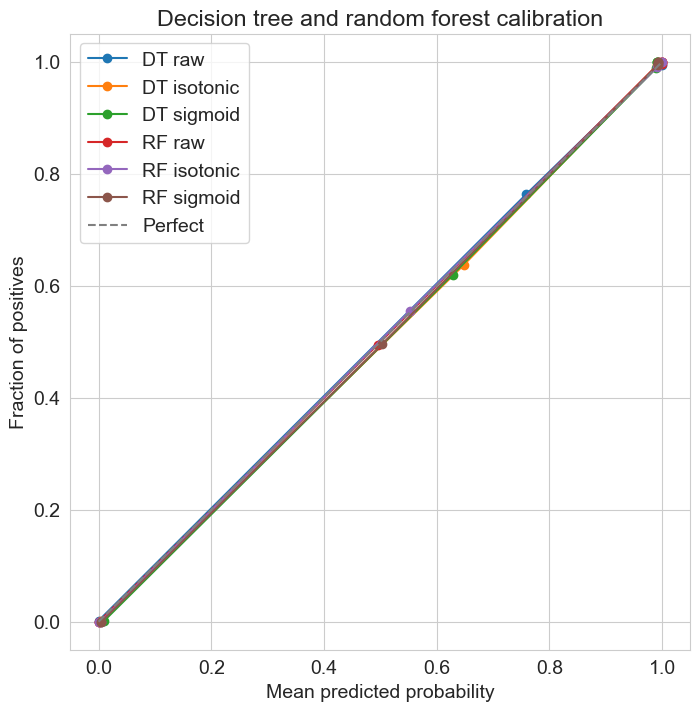

In [43]:
plt.figure(figsize=(8, 8))
curves_to_plot = [
    ('DT raw', dt_pred),
    ('DT isotonic', isotonic_dt_pred),
    ('DT sigmoid', sigmoid_dt_pred),
    ('RF raw', rf_final_pred),
    ('RF isotonic', isotonic_rf_final_pred),
    ('RF sigmoid', sigmoid_rf_final_pred),
]

for name, pred in curves_to_plot:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')
    plt.plot(pred_prob, true_prob, marker='o', label=name)

plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Decision tree and random forest calibration')
plt.legend()
plt.show()

??????: ????? ????? ????? ??????? ?? ?????????

**?????:** ????????? ?????? ???? ??????????? ? ????? ?????????? ???????????, ??????? ??? ?????? ?????????? ??????? ??????. ????????? ??? ?????? ???????? ??????????, ?? ????? ??????????? ????? ???? ????? ? ??????. ?????????? ???????? ???????????? ?????????; ?? ???? ???????? ??? ?????? ????? ????????? ?? ?????? ? ????????, ?? ? ? ECE/Brier/log-loss, ?????? ??? ? ????????? ????? ???? ????????.

**???????**: ????? ?? ??????????????? ? ????? ????? ???????????? (????? ????)? ???????? ? ?????????. ????? ?? ???????? ??????

In [44]:
all_candidates = {
    'SVC raw minmax': svc_pred,
    'LR raw': lr_pred,
    'GB raw': gb_pred,
    'RF raw': rf_pred,
    'SVC Platt': sigmoid_svc_pred,
    'LR Platt': sigmoid_lr_pred,
    'GB Platt': sigmoid_gb_pred,
    'RF Platt': sigmoid_rf_pred,
    'SVC isotonic': isotonic_svc_pred,
    'LR isotonic': isotonic_lr_pred,
    'GB isotonic': isotonic_gb_pred,
    'RF isotonic': isotonic_rf_pred,
    'DT raw': dt_pred,
    'DT Platt': sigmoid_dt_pred,
    'DT isotonic': isotonic_dt_pred,
    'RF final raw': rf_final_pred,
    'RF final Platt': sigmoid_rf_final_pred,
    'RF final isotonic': isotonic_rf_final_pred,
}

comparison = []
for name, pred in all_candidates.items():
    pred = np.clip(pred, 1e-15, 1 - 1e-15)
    comparison.append({
        'model': name,
        'ROC-AUC': roc_auc_score(y_test, pred),
        'ECE': binary_ECE(y_test, pred),
        'Brier': brier_score_loss(y_test, pred),
        'Log-loss': log_loss(y_test, np.column_stack([1 - pred, pred])),
    })

comparison = pd.DataFrame(comparison).sort_values(['ECE', 'Brier', 'Log-loss']).reset_index(drop=True)
display(comparison)

best_model = comparison.iloc[0]
print(f"?????? ?????????? ?? ECE: {best_model['model']} (ECE={best_model['ECE']:.4f}).")
print('??? ??????????? ????????????? ?????? ?? ?????? ? ??????? ECE/Brier ? ??? ???????? ???????? ROC-AUC.')

,model,ROC-AUC,ECE,Brier,Log-loss
0,RF isotonic,0.999128,0.002056,0.008148,0.031777
1,SVC isotonic,0.999099,0.002086,0.008211,0.030862
2,LR isotonic,0.998938,0.002151,0.008753,0.033625
3,GB isotonic,0.998995,0.002284,0.008319,0.031915
4,RF final raw,0.999125,0.002344,0.008078,0.031206
5,RF raw,0.999101,0.002561,0.008120,0.031454
6,RF Platt,0.999083,0.002611,0.008417,0.038909
7,SVC Platt,0.999134,0.002782,0.008191,0.031276
8,RF final Platt,0.999081,0.002862,0.008358,0.038414
9,RF final isotonic,0.999124,0.002980,0.008102,0.031492


?????? ?????????? ?? ECE: RF isotonic (ECE=0.0021).
??? ??????????? ????????????? ?????? ?? ?????? ? ??????? ECE/Brier ? ??? ???????? ???????? ROC-AUC.


Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).